<a href="https://colab.research.google.com/github/LeeSeongJinn/Doosan_Rokey_bootcamp/blob/main/2_Applied_AI/Day4/8_RAFT_opticalFlow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# RAFT Optical Flow 실습
**RAFT (Recurrent All-Pairs Field Transforms)** — ECCV 2020

---
## 실습 목표
1. torchvision 내장 RAFT 모델 로드
2. 웹에서 데이터 다운로드 → 연속 프레임 추출
3. 옵티컬 플로우 계산
4. 결과 시각화 (HSV 컬러맵, 화살표 벡터, 반복 보정 과정)

 **T4 GPU** 사용

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 112 not upgraded.
현재 설정된 폰트: NanumGothic


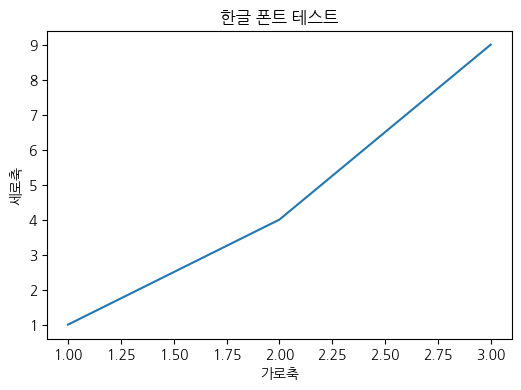

In [ ]:
# 1. 나눔 폰트 설치
!apt-get update -qq
!apt-get install -y fonts-nanum

# 2. matplotlib 캐시 삭제
import os
import shutil
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

cache_dir = mpl.get_cachedir()

if os.path.exists(cache_dir):
    shutil.rmtree(cache_dir)

# 3. 폰트 경로 직접 지정
font_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"

# 4. 폰트 등록
fm.fontManager.addfont(font_path)

# 5. 폰트 이름 가져오기
font_name = fm.FontProperties(fname=font_path).get_name()

# 6. matplotlib 기본 폰트 설정
plt.rcParams["font.family"] = font_name
plt.rcParams["axes.unicode_minus"] = False

print("현재 설정된 폰트:", font_name)

# 7. 테스트 그래프
plt.figure(figsize=(6, 4))
plt.title("한글 폰트 테스트")
plt.plot([1, 2, 3], [1, 4, 9])
plt.xlabel("가로축")
plt.ylabel("세로축")
plt.show()

In [ ]:
# 런타임 다시 시작

In [ ]:
# 패키지 설치 및 임포트
!pip install -q torchvision>=0.13 opencv-python-headless imageio[ffmpeg] requests

In [ ]:
import torch
import torchvision
import torchvision.transforms.functional as F
from torchvision.models.optical_flow import raft_large, raft_small
from torchvision.models.optical_flow import Raft_Large_Weights, Raft_Small_Weights
from torchvision.utils import flow_to_image
# flow_to_image : flow 벡터 >> HSV 컬러맵 변환

import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import requests, io, os, time

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"사용 디바이스: {device}")

사용 디바이스: cuda


In [ ]:
# 데이터 다운로드
# OPENCV 공식 테스트 영상
# https://raw.githubusercontent.com/opencv/opencv/master/samples/data/vtest.avi

video_url = 'https://raw.githubusercontent.com/opencv/opencv/master/samples/data/vtest.avi'
r = requests.get(video_url, timeout=30)
with open('vtest.avi', 'wb') as f:
    f.write(r.content)

영상 정보: 795 프레임, 10.00fps
프레임 크기: (768, 576), (768, 576)


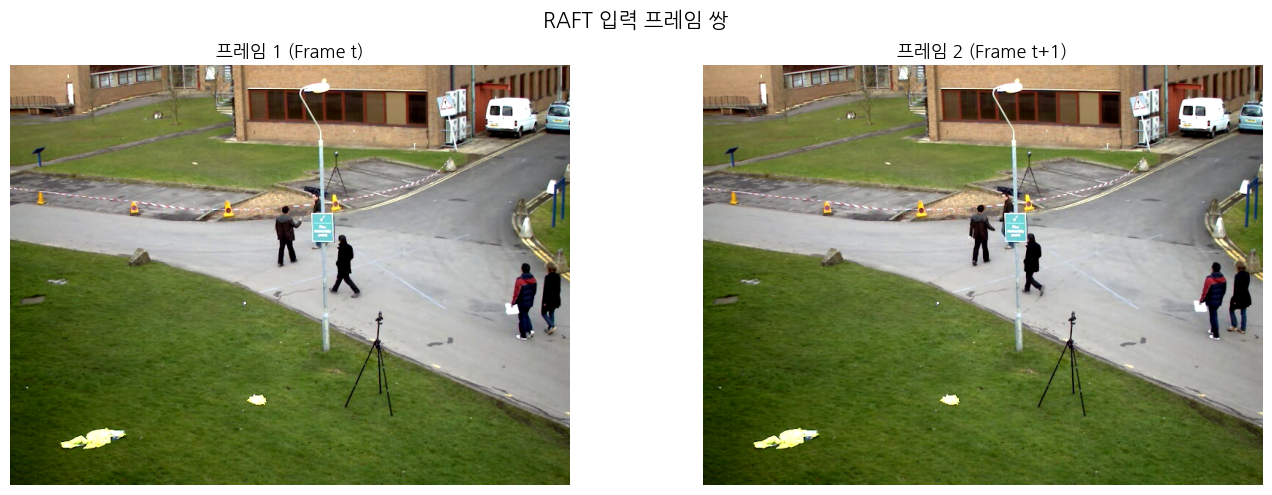

In [ ]:
cap = cv2.VideoCapture('vtest.avi')
total_frame = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
fps = cap.get(cv2.CAP_PROP_FPS)
print(f'영상 정보: {total_frame} 프레임, {fps:.2f}fps')


# 연속 2프레임 추출(20번째, 21번째)
frames = {}
for i in range(25):
    ret, frame = cap.read()
    if ret and i in [20, 21]:
        frames[i] = Image.fromarray(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
cap.release()


img1_pil, img2_pil = frames[20], frames[21]
print(f'프레임 크기: {img1_pil.size}, {img2_pil.size}')


fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].imshow(img1_pil); axes[0].set_title("프레임 1 (Frame t)", fontsize=13, fontweight="bold"); axes[0].axis("off")
axes[1].imshow(img2_pil); axes[1].set_title("프레임 2 (Frame t+1)", fontsize=13, fontweight="bold"); axes[1].axis("off")
plt.suptitle("RAFT 입력 프레임 쌍", fontsize=15, fontweight="bold")
plt.tight_layout(); plt.show()




## 3단계: RAFT 모델 구조


```
Image1, Image2
      │
      ▼
① Feature Encoder (CNN)  ← 256-dim 특징 추출
      │
      ▼
② All-Pairs Correlation  ← 모든 픽셀 쌍 유사도 → 4D 볼륨
      │
      ▼
③ Context Encoder        ← Image1 문맥 정보
      │
      ▼
④ Recurrent Update (GRU × N회)  ← 반복 보정
      │
      ▼
Flow Field (H × W × 2)  ← (Δx, Δy) 픽셀 이동 벡터
```


In [ ]:
# RAFT 모델 로드

model = raft_large(weights=Raft_Large_Weights.DEFAULT, progress=True)
model = model.to(device).eval()

total_params = sum(p.numel() for p in model.parameters())

print(f'전체 파라미터수: {total_params: ,}')

전체 파라미터수:  5,257,536


In [ ]:
def preprocess_for_raft(img_pil, device):
    # PIL Image >> RAFT 입력 텐서(8의 배수 패딩, [0,255] 범위)
    img_tensor = F.to_tensor(img_pil)
    H, W = img_tensor.shape[1], img_tensor.shape[2]
    H_new = (H//8) * 8
    W_new = (W//8) * 8
    #8의 배수인 이유: CNN 다운 샘플링 때문=> 1/2^3씩 줄움
    #나중에 업샘플링 고려하여 8의 배수로 맞춤
    imf_tensor=F.resize(img_tensor,[H_new,W_new],antialias=True)
    return img_tensor.unsqueeze(0).to(device),(H_new,W_new)
#unsqueeze(0) 배치 차원->[NCHW](1,3,H_new,W_new)
#(H_new,W_new) 크기 정보 반환


In [ ]:
img1_t,(H,W)=preprocess_for_raft(img1_pil,device)
img2_t,_=preprocess_for_raft(img2_pil,device)
print(f'RAFT 입력 텐서 크기: {img1_t.shape}')
print(f'범위:[{img1_t.min():.1f},{img1_t.max():.1f}]')

RAFT 입력 텐서 크기: torch.Size([1, 3, 576, 768])
범위:[0.0,1.0]


In [ ]:
with torch.no_grad():
    list_of_flows = model(img1_t, img2_t)
    # list_of_flows 반복해서 보정하는 과정

predicted_flow = list_of_flows[-1] # 최종 플로우
print(predicted_flow.shape)  # torch.Size([1, 2, 576, 768])
flow_np = predicted_flow[0].cpu().numpy()
print(flow_np.shape) # (2, 576, 768) >> (2, H, W)
# 여기서 2란? 각 픽셀이 다음 프레임(사진)에서 가로로 몇 픽셀, 세로로 몇 픽셀 이동했는지 나타냄
# print(flow_np[0]) # dx (x축 방향 이동량)
# print(flow_np[1]) # dy (y축 방향 이동량)

print(f"추론 완료! 반복 보정 횟수: {len(list_of_flows)}회")
print(f"플로우 shape: {predicted_flow.shape}  → [배치, 2(x+y), H, W]")
print(f"\n   X 방향: min={flow_np[0].min():.2f}px, max={flow_np[0].max():.2f}px")
print(f"   Y 방향: min={flow_np[1].min():.2f}px, max={flow_np[1].max():.2f}px")

torch.Size([1, 2, 576, 768])
(2, 576, 768)
추론 완료! 반복 보정 횟수: 12회
플로우 shape: torch.Size([1, 2, 576, 768])  → [배치, 2(x+y), H, W]

   X 방향: min=-13.95px, max=2.96px
   Y 방향: min=-3.61px, max=0.72px


6단계 : 결과 시각화


방법_1 : HSV 컬러맵
- 색상(Hue) >> 이동방향
- 밝기(Value) >> 이동속도


In [ ]:
flow_img=flow_to_image(predicted_flow[0])
flow_img.shape#torch.Size([3, 576, 768]) (3,h,w)

torch.Size([3, 576, 768])

In [ ]:
flow_img_np=flow_img.permute(1,2,0).cpu().numpy()
flow_img_np.shape # (576, 768, 3) (h,w,c)

(576, 768, 3)

In [ ]:
flow_img_np = flow_img.permute(1,2,0).cpu().numpy()
flow_img_np.shape # (576, 768, 3) >> (h, w, 3)

(576, 768, 3)

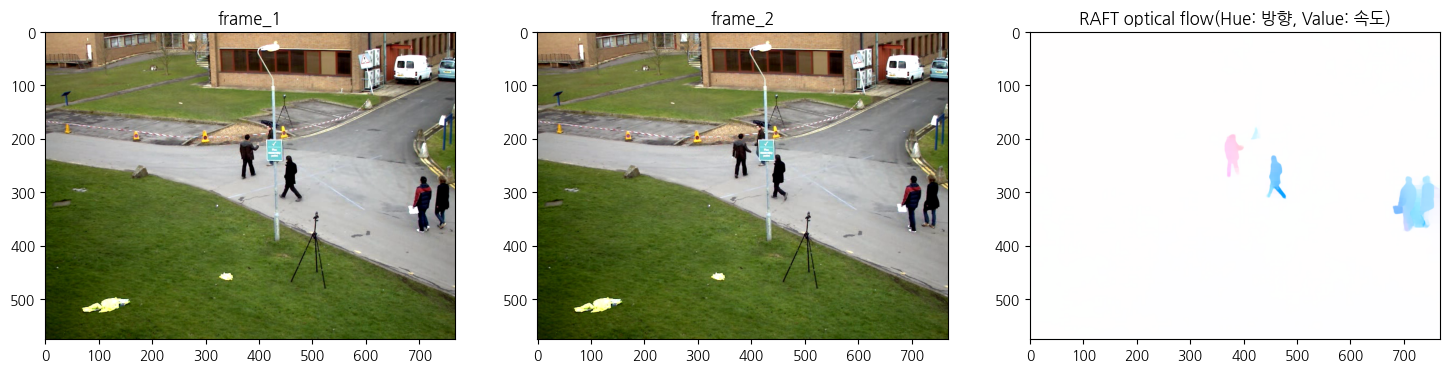

In [ ]:
img1_show = np.array(img1_pil.resize((W, H)))
img2_show = np.array(img2_pil.resize((W, H)))

fig, axes = plt.subplots(1,3, figsize=(18, 5))
axes[0].imshow(img1_show); axes[0].set_title('frame_1')
axes[1].imshow(img2_show); axes[1].set_title('frame_2')
axes[2].imshow(flow_img_np); axes[2].set_title('RAFT optical flow(Hue: 방향, Value: 속도)')
plt.show()

In [ ]:
# HSV 컬러맵 해석
# 1. 방향(색상)
# 2. 속도(밝기) 빠름(밝음), 느림(어두움)

# 밝을수록 빠르게 이동
# 어두울수록 느리게 이동(정지,느린 이동)
# 검정 : 정지

방법 2: 화살표 벡터 필드

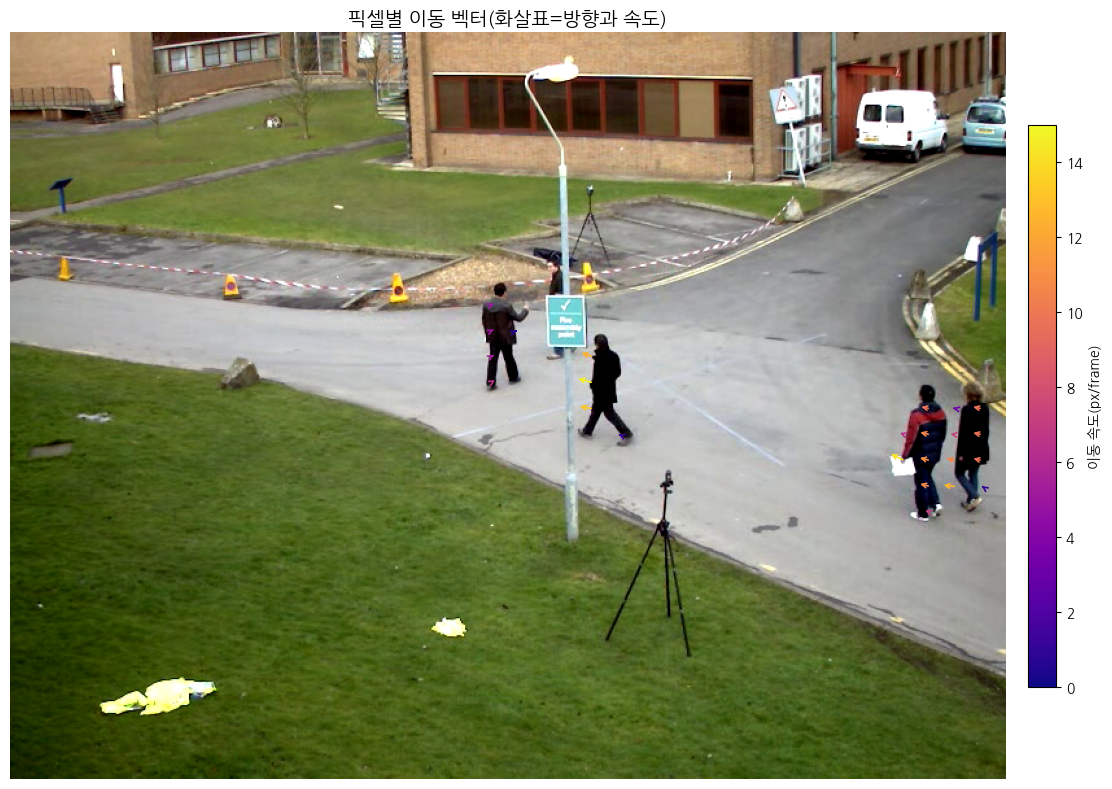

In [ ]:
from matplotlib.patches import ArrowStyle

def visualize_flow_arrows(img_np, flow_np, step=20, scale=2.0):
    H, W = img_np.shape[:2]
    flow_u, flow_v = flow_np[0], flow_np[1]
    fig, ax = plt.subplots(figsize=(12, 8))
    ax.imshow(img_np)
    # 20 pixel 간격으로 화살표를 그려줘
    for y in range(step//2, H, step):
        for x in range(step//2, W, step):
            u, v = flow_u[y, x] * scale, flow_v[y, x] * scale # 2배 확대
            mag = (u**2 + v**2) ** 0.5                         # 벡터 크기 계산
            if mag < 0.5: continue
            # 속도별 색상
            color = plt.cm.plasma(min(mag/15.0, 1.0))
            # plasma color map 보라(느림), 노랑(빠름)
            # 15pixel/frame 을 최대값으로 정규화
            ax.annotate("", xy=(x+u, y+v), xytext=(x,y),
                        # xytext=(x,y) 화살표 시작 위치, xy=(x+u, y+v) 화살표가 가리키는 끝 위치
                        # mutation_scale=8 화살촉 머리부분 위치 조절
                        arrowprops=dict(arrowstyle="->", color=color, lw=1.2, mutation_scale=8))

    sm = plt.cm.ScalarMappable(cmap='plasma', norm=plt.Normalize(0, 15)) # color bar
    plt.colorbar(sm, ax=ax, fraction=0.025, pad=0.02).set_label('이동 속도(px/frame)', fontsize=10)
    ax.set_title('픽셀별 이동 벡터(화살표=방향과 속도)', fontsize=14, fontweight="bold")
    ax.axis('off')
    return fig


fig = visualize_flow_arrows(img1_show, flow_np)
fig.savefig('RAFT_flow_arrows.png', dpi=150, bbox_inches='tight')


plt.tight_layout()
plt.show()

방법 3: 반복 보정 과정 시각화

In [ ]:
list_of_flows[0][0].shape # torch.Size([2, 576, 768])
# list_of_flows[idx] = list_of_flow[0] 해당 회차의 출력 값
# list_of_flows[0][0] 0번 채이에 있는 아이템 (dx: x축 이동량, dy: y축 이동량)

torch.Size([2, 576, 768])

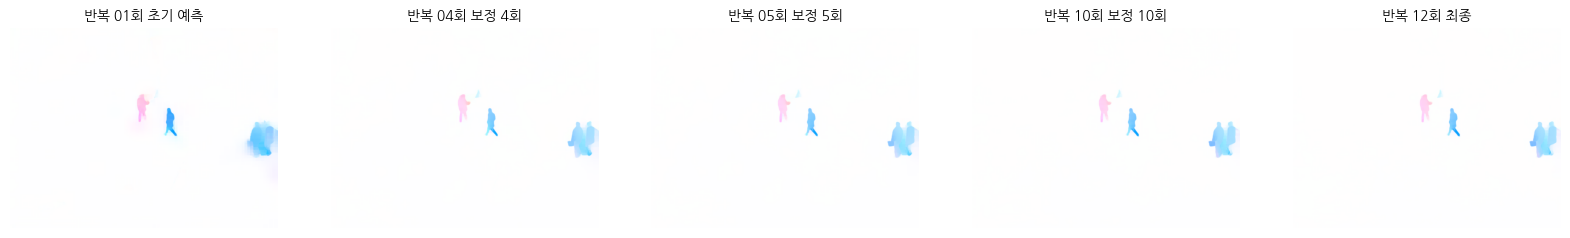

In [ ]:
n =len(list_of_flows)
indices = sorted(set([0, n//4, n//3, 3*n//4, n-1])) # [0, 3, 4, 9, 11]
fig, axes = plt.subplots(1, len(indices), figsize=(4*len(indices), 4))

for ax, idx in zip(axes, indices):
    fi = flow_to_image(list_of_flows[idx][0]).permute(1,2,0).cpu().numpy()
    label = '초기 예측' if idx==0 else ('최종' if idx == n-1 else f'보정 {idx+1}회') # 동적 라벨링
    ax.imshow(fi)
    ax.set_title(f'반복 {idx+1:02d}회 {label}', fontsize=10, fontweight='bold')
    ax.axis('off')

# 해석 : 초기 예측은 흐릿하나 반복할 수록 경계가 선명해짐

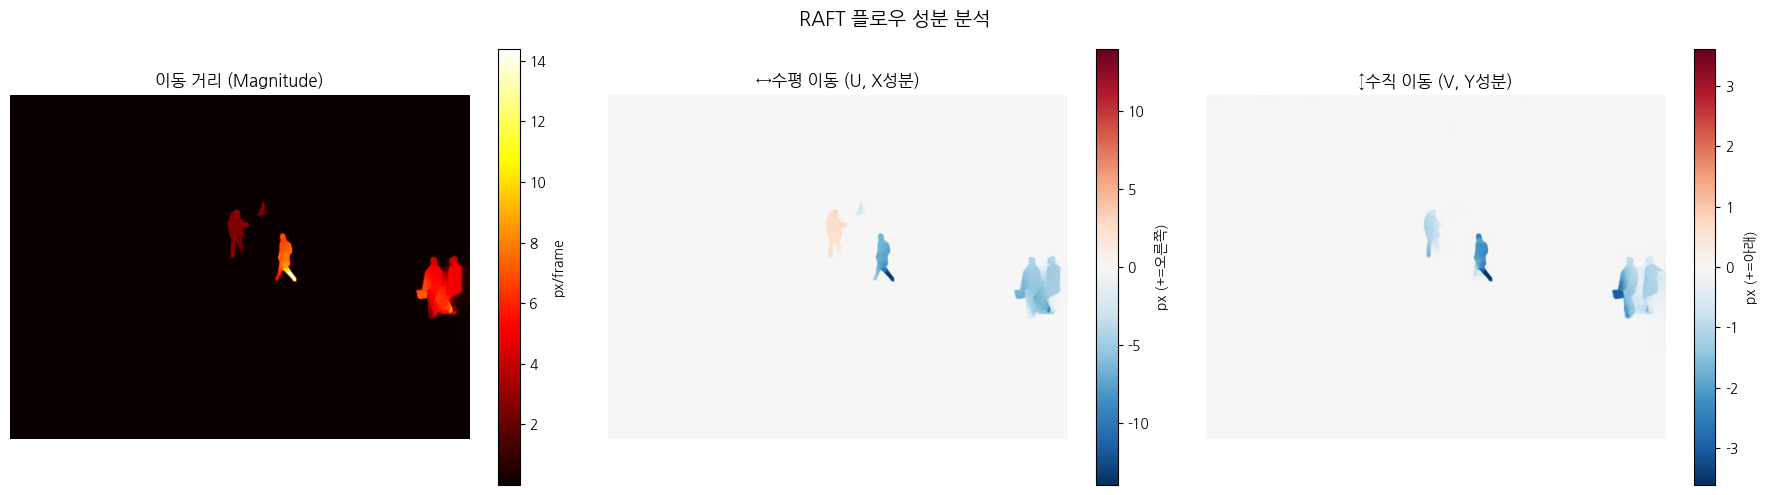

통계 요약:
  평균 이동 거리: 0.11 px
  최대 이동 거리: 14.39 px
  정지 픽셀 비율 (<0.5px): 97.9%
  빠른 픽셀 비율 (>5px):   0.9%


In [ ]:
flow_u = flow_np[0]
flow_v = flow_np[1]
magnitude = np.sqrt(flow_u ** 2 + flow_v ** 2)


fig, axes = plt.subplots(1, 3, figsize=(18, 5))


im0 = axes[0].imshow(magnitude, cmap="hot"); axes[0].set_title("이동 거리 (Magnitude)", fontsize=12, fontweight="bold"); axes[0].axis("off"); plt.colorbar(im0, ax=axes[0], label="px/frame")
vmax = max(abs(flow_u.min()), abs(flow_u.max()))
im1 = axes[1].imshow(flow_u, cmap="RdBu_r", vmin=-vmax, vmax=vmax); axes[1].set_title("↔수평 이동 (U, X성분)", fontsize=12, fontweight="bold"); axes[1].axis("off"); plt.colorbar(im1, ax=axes[1], label="px (+=오른쪽)")
vmax = max(abs(flow_v.min()), abs(flow_v.max()))
im2 = axes[2].imshow(flow_v, cmap="RdBu_r", vmin=-vmax, vmax=vmax); axes[2].set_title("↕수직 이동 (V, Y성분)", fontsize=12, fontweight="bold"); axes[2].axis("off"); plt.colorbar(im2, ax=axes[2], label="px (+=아래)")


plt.suptitle("RAFT 플로우 성분 분석", fontsize=14, fontweight="bold")
plt.tight_layout(); plt.savefig("raft_analysis.png", dpi=150, bbox_inches="tight"); plt.show()


print(f"통계 요약:")
print(f"  평균 이동 거리: {magnitude.mean():.2f} px")
print(f"  최대 이동 거리: {magnitude.max():.2f} px")
print(f"  정지 픽셀 비율 (<0.5px): {(magnitude < 0.5).mean()*100:.1f}%")
print(f"  빠른 픽셀 비율 (>5px):   {(magnitude > 5).mean()*100:.1f}%")




# 시각화 해석
# 수평이동일 경우 (강한 음수 - ) 왼쪽이동 (파란색), 흰색(정확히 0 정지상태), (강한 양수 +) 오른쪽 이동(빨간색)
# 수직이동일 경우 (강한 음수 - ) 위로 이동(파란색), 흰색(정확히 0 정지상태), (강항양수 +) 아래쪽으로 이동(빨간색)



8단계 : RAFT-Large vs RAFT-Small 비교

Downloading: "https://download.pytorch.org/models/raft_small_C_T_V2-01064c6d.pth" to /root/.cache/torch/hub/checkpoints/raft_small_C_T_V2-01064c6d.pth


100%|██████████| 3.82M/3.82M [00:00<00:00, 59.2MB/s]


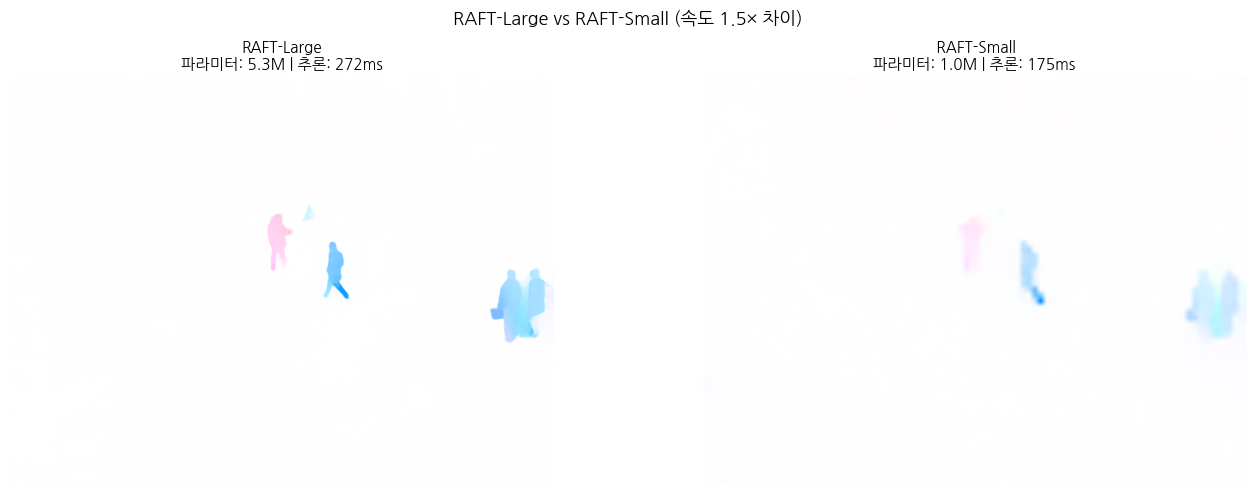


                          RAFT-Large      RAFT-Small
----------------------------------------------------
파라미터 수                          5.3M            1.0M
추론 시간                          272ms           175ms
속도 배율                           1.0×            1.5×


In [ ]:
model_small = raft_small(weights=Raft_Small_Weights.DEFAULT).to(device).eval()

N = 5
# Large 속도 측정
if device.type == "cuda": torch.cuda.synchronize() # 동기화
# GPU 추론 연산 끝날때까지 CPU 너 멈춰
t0 = time.time()
with torch.no_grad():
    for _ in range(N): fl = model(img1_t, img2_t)
if device.type == "cuda": torch.cuda.synchronize()
ms_large = (time.time()-t0)/N*1000

# Small 속도 측정
if device.type == "cuda": torch.cuda.synchronize()
t0 = time.time()
with torch.no_grad():
    for _ in range(N): fs = model_small(img1_t, img2_t)
if device.type == "cuda": torch.cuda.synchronize()
ms_small = (time.time()-t0)/N*1000

vis_large = flow_to_image(fl[-1][0]).permute(1,2,0).cpu().numpy()
vis_small = flow_to_image(fs[-1][0]).permute(1,2,0).cpu().numpy()
p_large = sum(p.numel() for p in model.parameters())
p_small = sum(p.numel() for p in model_small.parameters())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].imshow(vis_large); axes[0].set_title(f"RAFT-Large\n파라미터: {p_large/1e6:.1f}M | 추론: {ms_large:.0f}ms", fontsize=11, fontweight="bold"); axes[0].axis("off")
axes[1].imshow(vis_small); axes[1].set_title(f" RAFT-Small\n파라미터: {p_small/1e6:.1f}M | 추론: {ms_small:.0f}ms", fontsize=11, fontweight="bold"); axes[1].axis("off")
plt.suptitle(f"RAFT-Large vs RAFT-Small (속도 {ms_large/ms_small:.1f}× 차이)", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.savefig("raft_comparison.png", dpi=150, bbox_inches="tight"); plt.show()

print(f"\n{'':20s} {'RAFT-Large':>15s} {'RAFT-Small':>15s}")
print("-"*52)
print(f"{'파라미터 수':20s} {p_large/1e6:>14.1f}M {p_small/1e6:>14.1f}M")
print(f"{'추론 시간':20s} {ms_large:>13.0f}ms {ms_small:>13.0f}ms")
print(f"{'속도 배율':20s} {'1.0×':>15s} {ms_large/ms_small:>14.1f}×")